# ARIMA Time Series Forecasting


In [1]:
# ── Imports ──────────────────────────────────────────────────
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi']        = 120
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

# ── Configuration (change here to re-run for any ticker) ─────
TICKER      = 'TSLA'
ALL_TICKERS = ['TSLA', 'BND', 'SPY']   # used in portfolio section
START_DATE  = '2015-01-01'
END_DATE    = '2026-06-30'
TRAIN_END   = '2024-12-31'             # train up to end-2024, test on 2025

print(f'Ticker        : {TICKER}')
print(f'Portfolio     : {ALL_TICKERS}')
print(f'Full period   : {START_DATE} → {END_DATE}')
print(f'Training ends : {TRAIN_END}')

Ticker        : TSLA
Portfolio     : ['TSLA', 'BND', 'SPY']
Full period   : 2015-01-01 → 2026-06-30
Training ends : 2024-12-31


---
## Section 1 — Load & Explore Data

In [2]:
# Download single-asset data for ARIMA
raw   = yf.download(TICKER, start=START_DATE, end=END_DATE, auto_adjust=True)
price = raw['Close'].squeeze()   # squeeze() ensures it's a 1-D Series

print(f'Loaded {len(price)} trading days')
print(f'Date range : {price.index.min().date()} → {price.index.max().date()}')
print(f'Price range: ${price.min():.2f} → ${price.max():.2f}')
raw[['Close','Volume']].head()

[*********************100%***********************]  1 of 1 completed

Loaded 2888 trading days
Date range : 2015-01-02 → 2026-06-29
Price range: $9.58 → $489.88


Price,Close,Volume
Ticker,TSLA,TSLA
Date,,
2015-01-02,14.620667,71466000
2015-01-05,14.006000,80527500
2015-01-06,14.085333,93928500
2015-01-07,14.063333,44526000
2015-01-08,14.041333,51637500


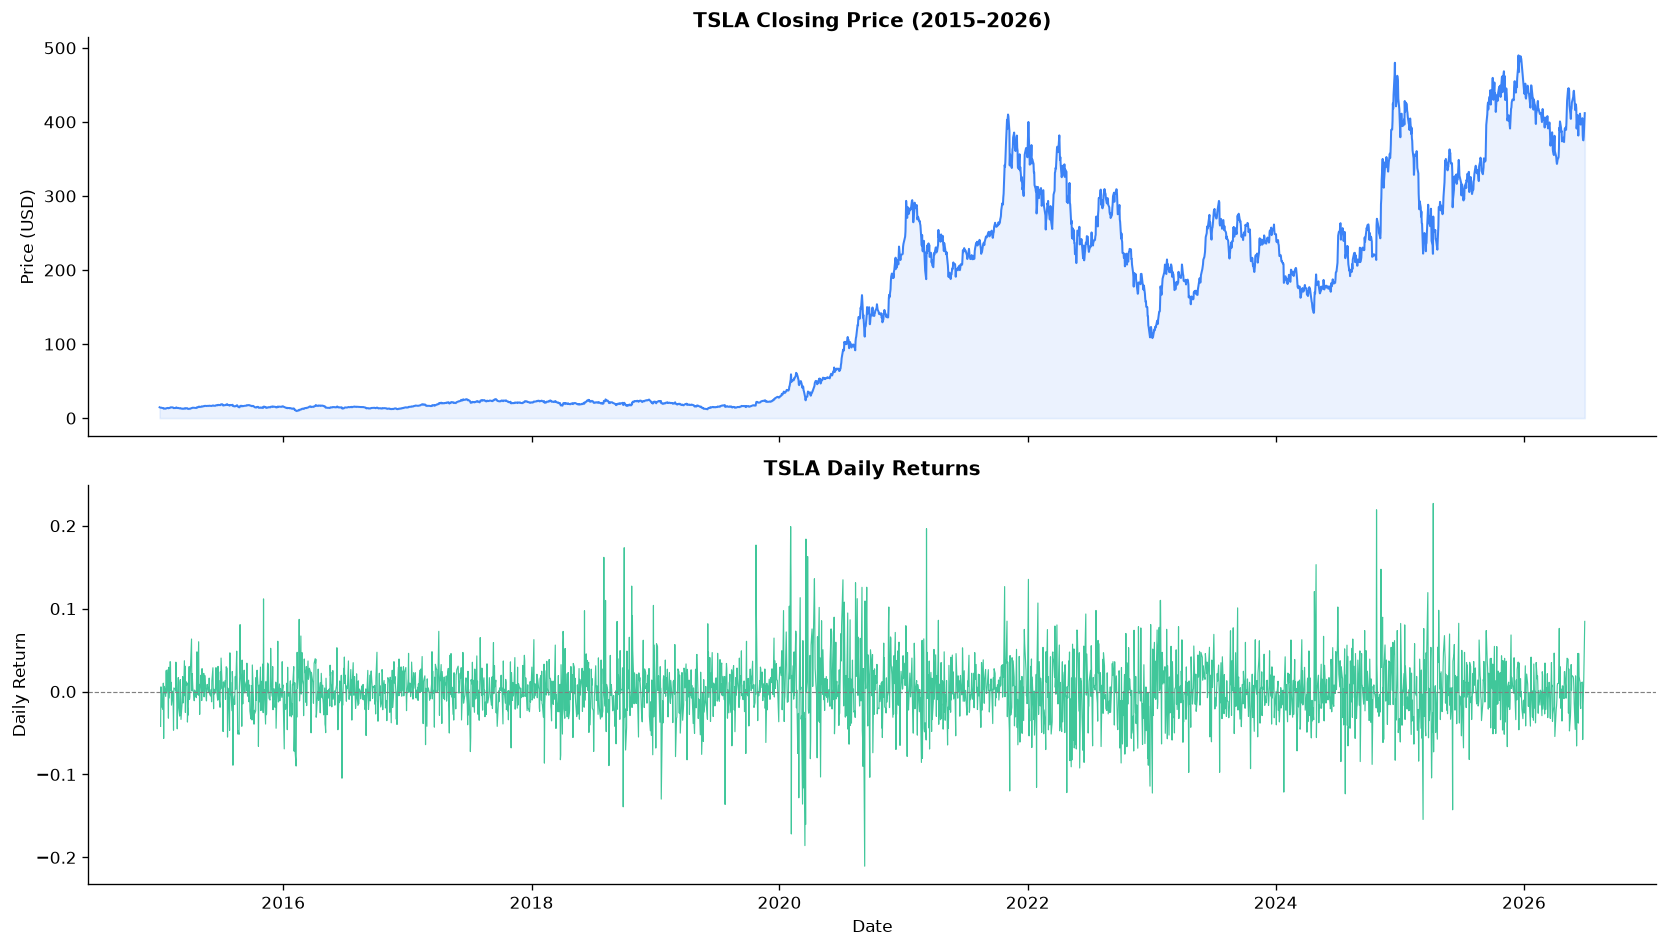

Summary statistics:
count    2887.0000
mean        0.0018
std         0.0360
min        -0.2106
25%        -0.0166
50%         0.0012
75%         0.0195
max         0.2269
Name: TSLA, dtype: float64


In [3]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Closing price
axes[0].plot(price, color='#3B82F6', linewidth=1.2)
axes[0].fill_between(price.index, price, alpha=0.1, color='#3B82F6')
axes[0].set_title(f'{TICKER} Closing Price (2015–2026)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Price (USD)')

# Daily returns
returns = price.pct_change().dropna()
axes[1].plot(returns, color='#10B981', linewidth=0.7, alpha=0.8)
axes[1].axhline(0, color='gray', linewidth=0.7, linestyle='--')
axes[1].set_title(f'{TICKER} Daily Returns', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Daily Return')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.show()

print('Summary statistics:')
print(returns.describe().round(4))

---
## Section 2 — Stationarity Testing

**Why it matters:** ARIMA needs stationary data — a series whose mean and variance are constant over time.
- Raw prices **trend upward** → non-stationary
- Daily returns **oscillate around 0** → stationary

We confirm this formally with the **Augmented Dickey-Fuller (ADF) test**:
- p-value **< 0.05** → stationary ✅
- p-value **≥ 0.05** → non-stationary ❌

In [4]:
def adf_test(series, name):
    res     = adfuller(series.dropna())
    p       = res[1]
    verdict = 'STATIONARY ✅' if p < 0.05 else 'NON-STATIONARY ❌'
    print(f'  {name:<20}  ADF={res[0]:8.4f}  p={p:.6f}  →  {verdict}')
    return p

print('─── ADF Test Results ───')
adf_test(price,   'TSLA Price')
adf_test(returns, 'TSLA Returns')

print()
print('Conclusion: model ARIMA on RETURNS (d=0), then convert back to prices.')

─── ADF Test Results ───
  TSLA Price            ADF= -1.0696  p=0.727042  →  NON-STATIONARY ❌
  TSLA Returns          ADF=-53.9719  p=0.000000  →  STATIONARY ✅

Conclusion: model ARIMA on RETURNS (d=0), then convert back to prices.


---
## Section 3 — Select ARIMA Parameters with ACF / PACF


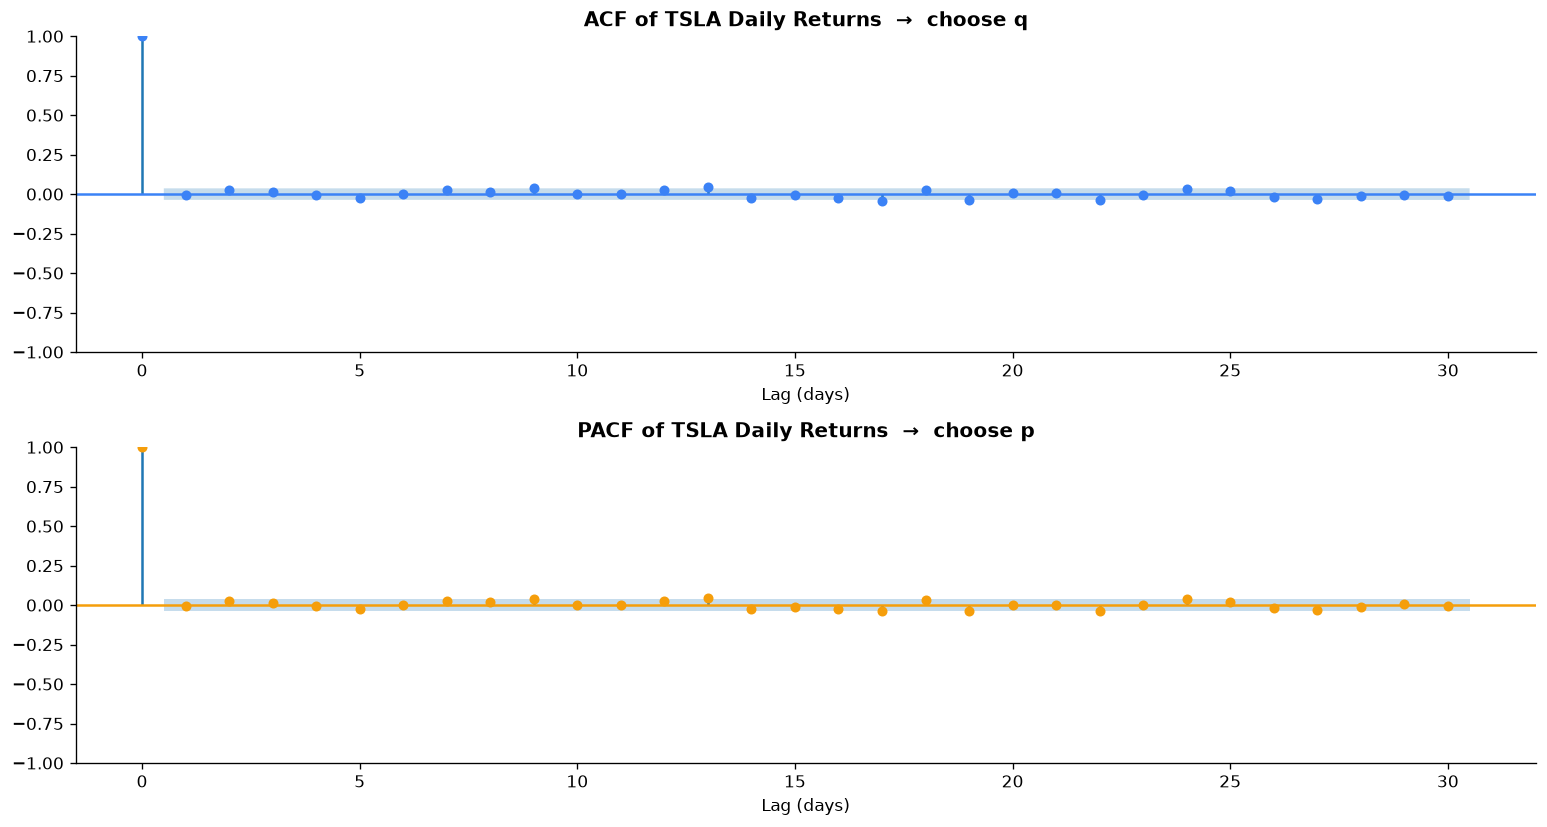

For most stock return series, p=1 and q=1 is a good starting point.
If ACF cuts off at lag 1 → q=1. If PACF cuts off at lag 1 → p=1.
We use ARIMA(1, 0, 1).


In [5]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7))

plot_acf(returns.dropna(),  lags=30, ax=ax1, color='#3B82F6')
ax1.set_title('ACF of TSLA Daily Returns  →  choose q', fontsize=12, fontweight='bold')
ax1.set_xlabel('Lag (days)')

plot_pacf(returns.dropna(), lags=30, ax=ax2, color='#F59E0B', method='ywm')
ax2.set_title('PACF of TSLA Daily Returns  →  choose p', fontsize=12, fontweight='bold')
ax2.set_xlabel('Lag (days)')

plt.tight_layout()
plt.show()

print('For most stock return series, p=1 and q=1 is a good starting point.')
print('If ACF cuts off at lag 1 → q=1. If PACF cuts off at lag 1 → p=1.')
print('We use ARIMA(1, 0, 1).')

---
## Section 4 — Train / Test Split & Fit ARIMA



In [6]:
# Chronological split
train_price   = price.loc[:TRAIN_END]
test_price    = price.loc[TRAIN_END:].iloc[1:]   # skip overlap row
train_returns = returns.loc[:TRAIN_END]
test_returns  = returns.loc[TRAIN_END:].iloc[1:]

print(f'Training : {len(train_price):4d} days  ({train_price.index[0].date()} → {train_price.index[-1].date()})')
print(f'Test     : {len(test_price):4d} days  ({test_price.index[0].date()} → {test_price.index[-1].date()})')

Training : 2516 days  (2015-01-02 → 2024-12-31)
Test     :  372 days  (2025-01-02 → 2026-06-29)


In [7]:
# Fit ARIMA(1, 0, 1) on training returns
# d=0 because returns are already stationary
print('Fitting ARIMA(1, 0, 1) on TSLA training returns...')
model     = ARIMA(train_returns, order=(1, 0, 1))
model_fit = model.fit()
print(model_fit.summary())

print()
print('What to look for in the summary:')
print('  • ar.L1 P>|z| < 0.05  →  yesterday returns help predict today  (AR term is useful)')
print('  • ma.L1 P>|z| < 0.05  →  yesterday error   helps correct today  (MA term is useful)')
print('  • AIC/BIC: lower = better model fit')

Fitting ARIMA(1, 0, 1) on TSLA training returns...
                               SARIMAX Results                                
Dep. Variable:                   TSLA   No. Observations:                 2515
Model:                 ARIMA(1, 0, 1)   Log Likelihood                4792.757
Date:                Sun, 05 Jul 2026   AIC                          -9577.514
Time:                        15:26:56   BIC                          -9554.194
Sample:                             0   HQIC                         -9569.050
                               - 2515                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0020      0.001      2.441      0.015       0.000       0.004
ar.L1          0.8639      0.143      6.027      0.000       0.583       1.145
m

---
## Section 5 — Forecast & Convert to Prices


In [8]:
# ── Forecast returns for the test period ──
n_steps        = len(test_returns)
fc_result      = model_fit.get_forecast(steps=n_steps)
fc_returns_arr = fc_result.predicted_mean.values

# Align index
fc_returns_s = pd.Series(fc_returns_arr, index=test_returns.index)

# ── Convert returns → prices (compound formula) ──
last_train_price  = float(train_price.iloc[-1])
fc_prices_central = last_train_price * np.cumprod(1 + fc_returns_arr)

# ── 95% confidence cone using √t scaling (random walk property) ──
daily_std  = float(train_returns.std())
days_ahead = np.arange(1, n_steps + 1)
price_cone = last_train_price * daily_std * np.sqrt(days_ahead)
z          = 1.96
fc_upper   = fc_prices_central + z * price_cone
fc_lower   = fc_prices_central - z * price_cone

print(f'Last known price  : ${last_train_price:.2f}')
print(f'Daily return std  : {daily_std*100:.3f}%')
print()
print(f'{"Horizon":>10}  {"Forecast":>10}  {"Lower":>9}  {"Upper":>9}  {"Band Width":>11}')
print('-' * 56)
for d in [1, 5, 20, 60, n_steps-1]:
    print(f'{d:>10}d  ${fc_prices_central[d]:>9.2f}  ${fc_lower[d]:>8.2f}  '
          f'${fc_upper[d]:>8.2f}  ${fc_upper[d]-fc_lower[d]:>10.2f}')

Last known price  : $403.84
Daily return std  : 3.601%

   Horizon    Forecast      Lower      Upper   Band Width
--------------------------------------------------------
         1d  $   404.71  $  364.40  $  445.02  $     80.62
         5d  $   406.95  $  337.13  $  476.76  $    139.63
        20d  $   417.97  $  287.36  $  548.59  $    261.22
        60d  $   451.79  $  229.18  $  674.40  $    445.21
       371d  $   829.29  $  279.56  $ 1379.01  $   1099.45


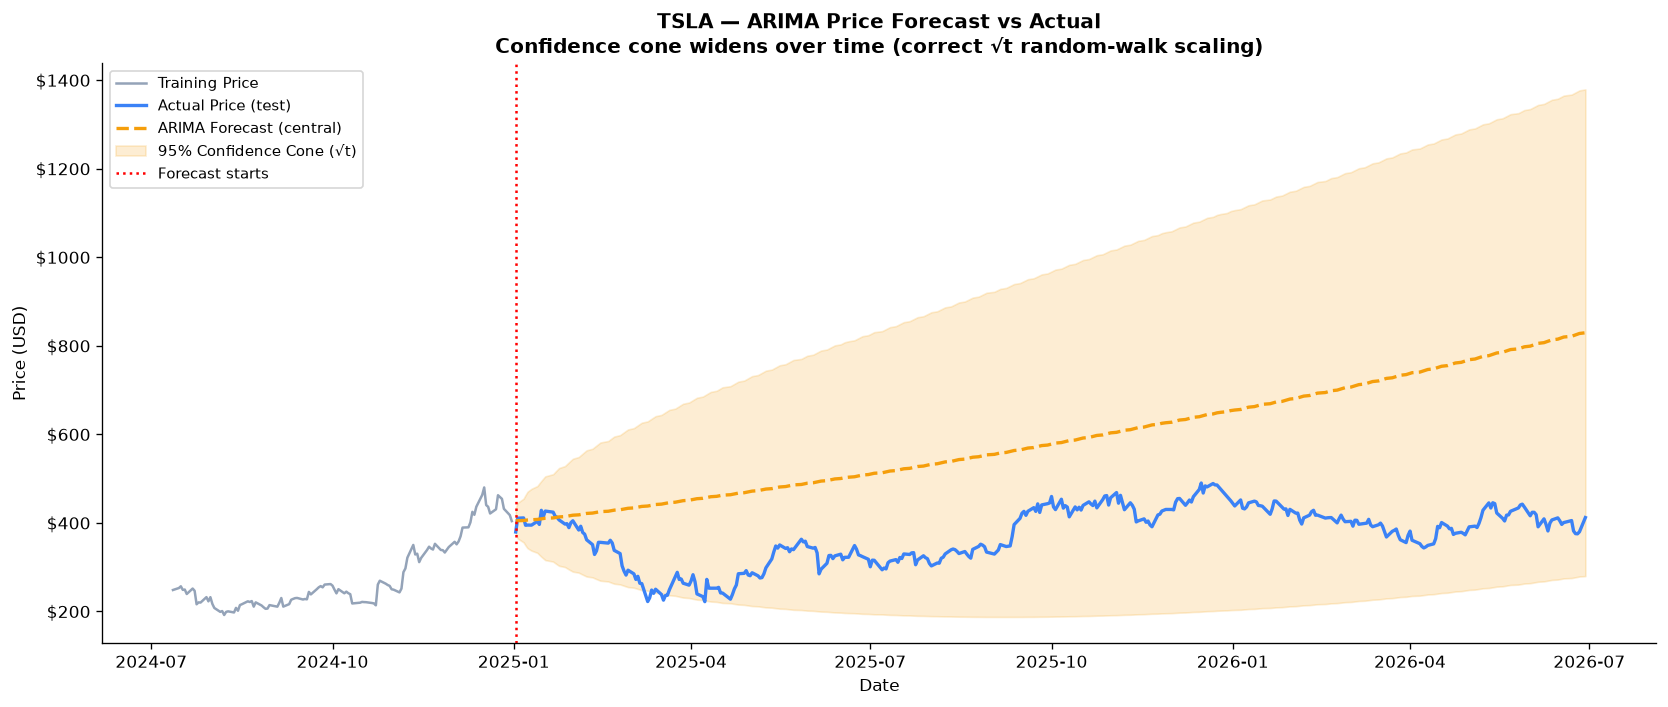

In [9]:
fig, ax = plt.subplots(figsize=(14, 6))

# Show last 120 days of training for context
hist = train_price.iloc[-120:]
ax.plot(hist.index, hist.values, color='#94A3B8', lw=1.5, label='Training Price')

# Actual test prices
ax.plot(test_price.index, test_price.values, color='#3B82F6', lw=2.0, label='Actual Price (test)')

# Forecasted price path
ax.plot(test_returns.index, fc_prices_central, color='#F59E0B',
        lw=2.0, linestyle='--', label='ARIMA Forecast (central)')

# Confidence cone
ax.fill_between(test_returns.index, fc_lower, fc_upper,
                alpha=0.18, color='#F59E0B', label='95% Confidence Cone (√t)')

ax.axvline(test_returns.index[0], color='red', lw=1.5, linestyle=':', label='Forecast starts')
ax.set_title(f'{TICKER} — ARIMA Price Forecast vs Actual\n'
             'Confidence cone widens over time (correct √t random-walk scaling)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Price (USD)')
ax.set_xlabel('Date')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'${y:.0f}'))
ax.legend(fontsize=9, loc='upper left')
plt.tight_layout()
plt.show()

---
## Section 6 — Evaluate Forecast Accuracy


In [ ]:
fc_price_series = pd.Series(fc_prices_central, index=test_returns.index)
actual_aligned  = test_price.reindex(fc_price_series.index).dropna()
fc_aligned      = fc_price_series.reindex(actual_aligned.index)

mae  = mean_absolute_error(actual_aligned, fc_aligned)
rmse = np.sqrt(mean_squared_error(actual_aligned, fc_aligned))
mape = np.mean(np.abs((actual_aligned - fc_aligned) / actual_aligned)) * 100

print('='*45)
print('  ARIMA(1,0,1) — TSLA Forecast Metrics')
print('='*45)
print(f'  MAE  (Mean Absolute Error)  : ${mae:.2f}')
print(f'  RMSE (Root Mean Sq Error)   : ${rmse:.2f}')
print(f'  MAPE (Mean Abs % Error)     : {mape:.2f}%')
print()
print('Note: TSLA is one of the most volatile stocks — high error is expected.')
print('ARIMA captures the DIRECTION and RANGE, not the exact daily price.')



  ARIMA(1,0,1) — TSLA Forecast Metrics
  MAE  (Mean Absolute Error)  : $217.85
  RMSE (Root Mean Sq Error)   : $240.16
  MAPE (Mean Abs % Error)     : 59.97%

Note: TSLA is one of the most volatile stocks — high error is expected.
ARIMA captures the DIRECTION and RANGE, not the exact daily price.


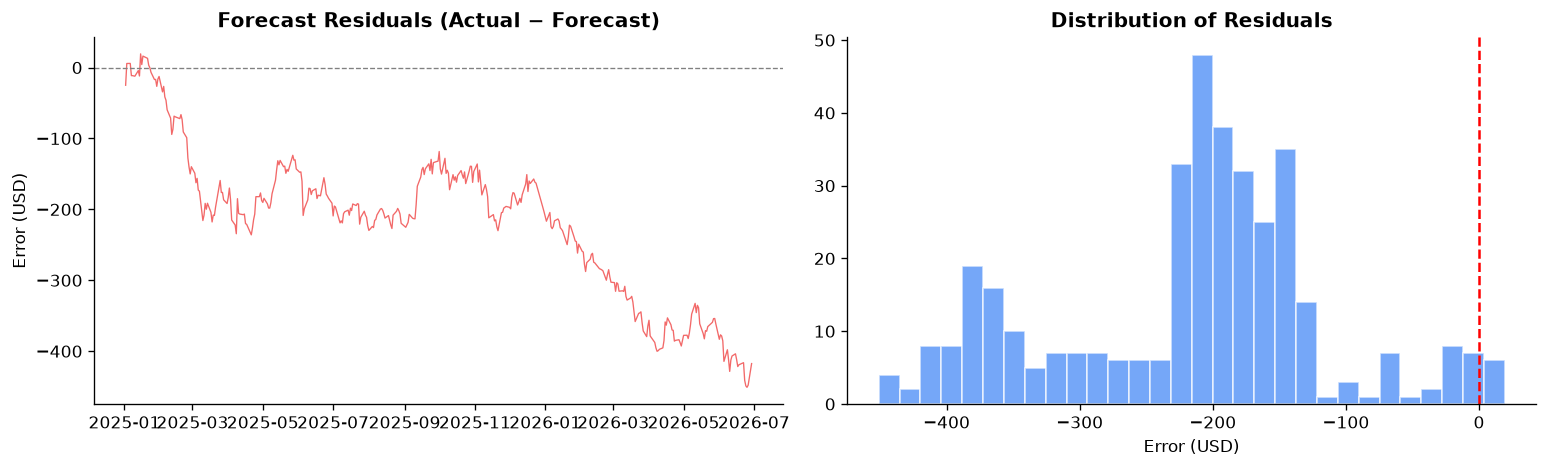

In [16]:
# Residual plot
residuals = actual_aligned.values - fc_aligned.values
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(actual_aligned.index, residuals, color='#EF4444', lw=0.8, alpha=0.8)
ax1.axhline(0, color='gray', lw=0.8, linestyle='--')
ax1.set_title('Forecast Residuals (Actual − Forecast)', fontweight='bold')
ax1.set_ylabel('Error (USD)')
ax2.hist(residuals, bins=30, color='#3B82F6', alpha=0.7, edgecolor='white')
ax2.axvline(0, color='red', lw=1.5, linestyle='--')
ax2.set_title('Distribution of Residuals', fontweight='bold')
ax2.set_xlabel('Error (USD)')
plt.tight_layout()
plt.show()

---
## Section 7 — Portfolio Optimization 



In [11]:
# Download all three assets for the TRAINING period only
# (we must not let portfolio estimation use future data)
print('Downloading TSLA, BND, SPY for portfolio optimization...')
port_raw    = yf.download(ALL_TICKERS, start=START_DATE, end=TRAIN_END, auto_adjust=True)
port_prices = port_raw['Close'].dropna()
port_returns = port_prices.pct_change().dropna()

print(f'Portfolio data: {len(port_prices)} trading days')
print()
print('Historical Annual Returns:')
hist_mu = port_returns.mean() * 252
for t in ALL_TICKERS:
    print(f'  {t}: {hist_mu[t]*100:.2f}%/year (historical)')

# ARIMA-forecasted annual return for TSLA
arima_tsla_return = float(fc_returns_s.mean() * 252)
print(f'\n  TSLA: {arima_tsla_return*100:.2f}%/year  ← ARIMA forecast (replaces historical)')

# Build expected return vector: TSLA = forecasted, BND/SPY = historical
mu_vec = hist_mu.copy()
mu_vec['TSLA'] = arima_tsla_return

# Annualized covariance matrix
cov_matrix = port_returns.cov() * 252
print()
print('Correlation Matrix:')
print(port_returns.corr().round(3))

[*********************100%***********************]  3 of 3 completed

Portfolio data: 2515 trading days

Historical Annual Returns:
  TSLA: 49.88%/year (historical)
  BND: 1.53%/year (historical)
  SPY: 13.85%/year (historical)

  TSLA: 48.79%/year  ← ARIMA forecast (replaces historical)

Correlation Matrix:
Ticker    BND    SPY   TSLA
Ticker                     
BND     1.000  0.108  0.056
SPY     0.108  1.000  0.466
TSLA    0.056  0.466  1.000


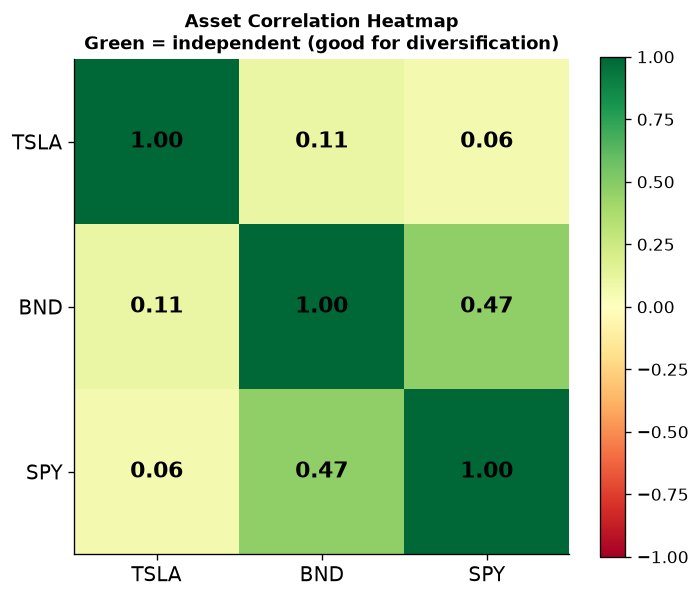

Low TSLA-BND correlation = bonds buffer TSLA crashes. That is why we mix them.


In [12]:
corr = port_returns.corr()
fig, ax = plt.subplots(figsize=(6, 5))
img = ax.imshow(corr.values, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(img, ax=ax)
ax.set_xticks(range(3)); ax.set_xticklabels(ALL_TICKERS, fontsize=12)
ax.set_yticks(range(3)); ax.set_yticklabels(ALL_TICKERS, fontsize=12)
for i in range(3):
    for j in range(3):
        ax.text(j, i, f'{corr.values[i,j]:.2f}',
                ha='center', va='center', fontsize=13, fontweight='bold')
ax.set_title('Asset Correlation Heatmap\nGreen = independent (good for diversification)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

print('Low TSLA-BND correlation = bonds buffer TSLA crashes. That is why we mix them.')

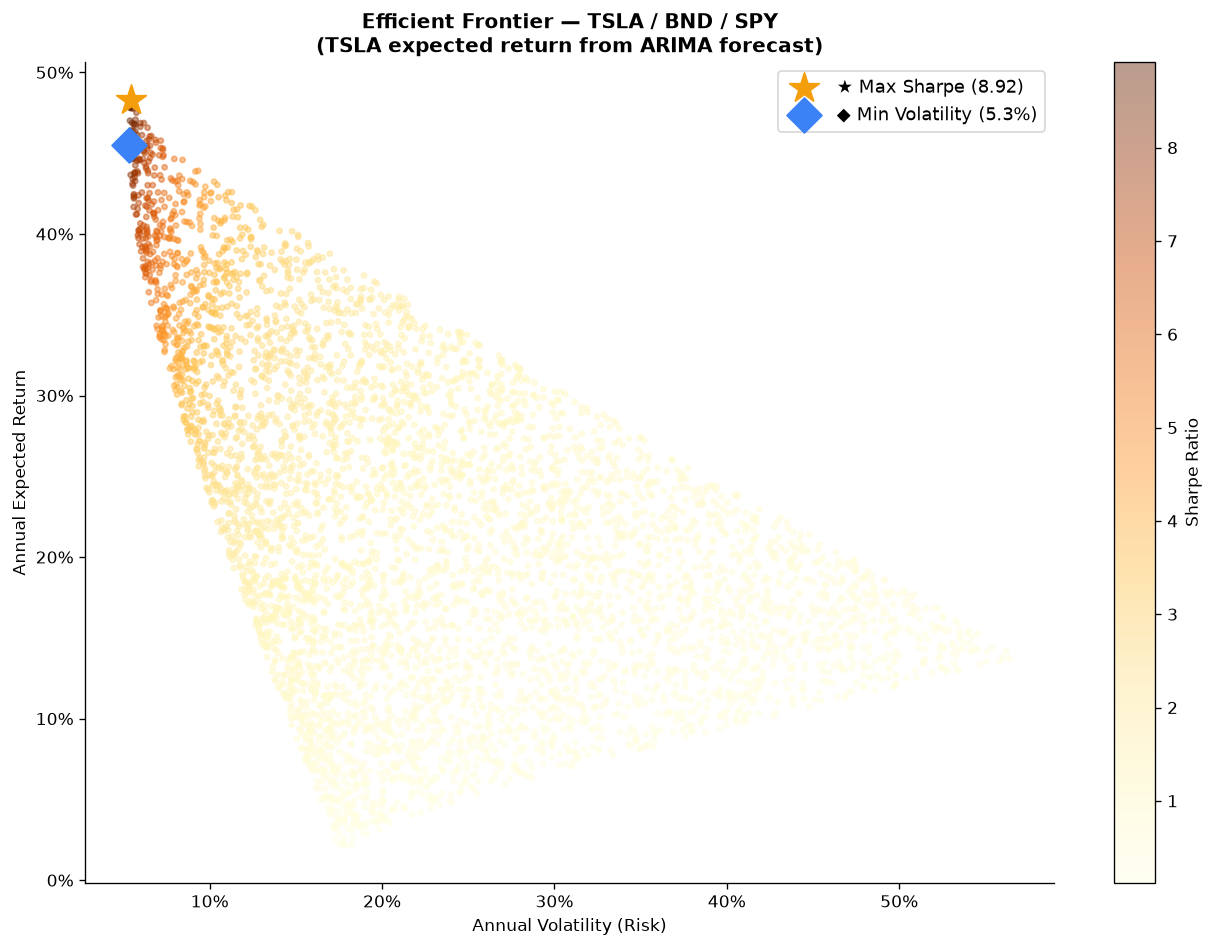

In [13]:
# Monte Carlo: generate 5,000 random portfolios
N   = 5000
rng = np.random.default_rng(seed=42)

p_rets, p_vols, p_sharpes, p_weights = [], [], [], []

for _ in range(N):
    w = rng.dirichlet(np.ones(3))                    # random weights summing to 1
    r = np.dot(w, mu_vec[ALL_TICKERS])               # portfolio return
    v = np.sqrt(np.dot(w, np.dot(cov_matrix, w)))    # portfolio volatility
    s = r / v                                        # Sharpe ratio
    p_rets.append(r); p_vols.append(v)
    p_sharpes.append(s); p_weights.append(w)

p_rets    = np.array(p_rets)
p_vols    = np.array(p_vols)
p_sharpes = np.array(p_sharpes)

idx_sharpe = np.argmax(p_sharpes)
idx_minvol = np.argmin(p_vols)

# Plot Efficient Frontier
fig, ax = plt.subplots(figsize=(11, 8))
sc = ax.scatter(p_vols, p_rets, c=p_sharpes, cmap='YlOrBr', alpha=0.45, s=10)
plt.colorbar(sc, ax=ax, label='Sharpe Ratio')
ax.scatter(p_vols[idx_sharpe], p_rets[idx_sharpe], s=350, marker='*',
           color='#F59E0B', zorder=5, label=f'★ Max Sharpe ({p_sharpes[idx_sharpe]:.2f})')
ax.scatter(p_vols[idx_minvol], p_rets[idx_minvol], s=220, marker='D',
           color='#3B82F6', zorder=5, label=f'◆ Min Volatility ({p_vols[idx_minvol]*100:.1f}%)')
ax.set_title('Efficient Frontier — TSLA / BND / SPY\n'
             '(TSLA expected return from ARIMA forecast)', fontsize=12, fontweight='bold')
ax.set_xlabel('Annual Volatility (Risk)')
ax.set_ylabel('Annual Expected Return')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y*100:.0f}%'))
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [14]:
def show_portfolio(label, idx):
    print(f'\n{"="*52}')
    print(f'  {label}')
    print(f'{"="*52}')
    for ticker, w in zip(ALL_TICKERS, p_weights[idx]):
        bar = '█' * int(w * 40)
        print(f'  {ticker}: {w*100:5.1f}%   {bar}')
    print(f'  Expected Annual Return    : {p_rets[idx]*100:.2f}%')
    print(f'  Expected Annual Volatility: {p_vols[idx]*100:.2f}%')
    print(f'  Sharpe Ratio              : {p_sharpes[idx]:.3f}')

show_portfolio('★ Maximum Sharpe Ratio Portfolio  (RECOMMENDED)', idx_sharpe)
show_portfolio('◆ Minimum Volatility Portfolio  (CONSERVATIVE)', idx_minvol)

print()
print('─── Investment Memo Summary ───')
print('TSLA contributes high potential return but also high risk.')
print('BND acts as a shock absorber — low correlation with stocks.')
print('SPY provides diversified market exposure at moderate risk.')
print('The optimal blend depends on the client\'s risk tolerance:')
print('  • Risk-tolerant  → lean toward Max Sharpe (more TSLA/SPY)')
print('  • Conservative   → lean toward Min Vol    (more BND)')


  ★ Maximum Sharpe Ratio Portfolio  (RECOMMENDED)
  TSLA:  98.9%   ███████████████████████████████████████
  BND:   0.7%   
  SPY:   0.3%   
  Expected Annual Return    : 48.32%
  Expected Annual Volatility: 5.42%
  Sharpe Ratio              : 8.916

  ◆ Minimum Volatility Portfolio  (CONSERVATIVE)
  TSLA:  93.1%   █████████████████████████████████████
  BND:   6.9%   ██
  SPY:   0.0%   
  Expected Annual Return    : 45.52%
  Expected Annual Volatility: 5.34%
  Sharpe Ratio              : 8.520

─── Investment Memo Summary ───
TSLA contributes high potential return but also high risk.
BND acts as a shock absorber — low correlation with stocks.
SPY provides diversified market exposure at moderate risk.
The optimal blend depends on the client's risk tolerance:
  • Risk-tolerant  → lean toward Max Sharpe (more TSLA/SPY)
  • Conservative   → lean toward Min Vol    (more BND)
